# Regression and Variational Autoencoders for DNA Methylation–Based Cell Type Estimation


## Introduction

This project looks at the DNA fragments that circulate in the blood. These fragments come from many different cell types in the body. When tissues are damaged or diseased, they release more DNA than usual, so the mix of DNA in the blood changes. By figuring out which cell types the DNA comes from, we can get an early picture of tissue health (as an example in a [COVID study](https://doi.org/10.1172/jci.insight.147610), and in [cancer](https://doi.org/10.1038/nrc.2017.7). This could become a powerful, non-invasive way to detect and monitor diseases—such as cancer—using nothing more than a routine blood test.

Traditionally, researchers study what types of cells are present in a tissue sample by using methods like staining cells under a microscope, sorting them, or sequencing single cells. Another way is to look at [DNA methylation](https://www.sciencedirect.com/topics/biochemistry-genetics-and-molecular-biology/methylome), which acts like a chemical “fingerprint” that is unique to each cell type. By reading these fingerprints, we can estimate how much DNA comes from each cell type in a mixed sample, such as blood.


## Methods

### Regression-based

I first applied established regression-based deconvolution methods to estimate cell type proportions from bulk DNA methylation data. These methods assume that the observed methylation profile is a weighted mixture of reference profiles from individual cell types. By solving for the weights, I obtain the estimated cell type fractions. Specifically, I tested **non-negative least squares (NNLS)**, constrained optimization (enforcing weights to sum to one), **ridge regression**, **lasso regression**, and **elastic net** regression. Each method was applied to simulated datasets generated with known ground-truth proportions, allowing us to directly evaluate accuracy. I compared performance across multiple conditions, including different levels of noise, numbers of CpGs, and varying similarity between cell types. This design follows the benchmarking review by de Ridder et al. [\[DOI: 10.1038/s41467-024-48466-z\]](https://doi.org/10.1038/s41467-024-48466-z).


### Deep learning - variational autoencoder

In addition to regression approaches, I implemented a **variational autoencoder (VAE)** with an additional output head to predict cell type proportions. The VAE is trained to reconstruct CpG methylation profiles while simultaneously learning to predict the proportion of each cell type in the mixture. The encoder maps input methylation profiles into a latent representation, from which both the reconstructed profiles and predicted proportions are derived. Training was performed using a combined loss function consisting of (i) reconstruction error, (ii) supervised proportion error, and (iii) a regularization term (KL divergence). This approach allows the model to capture complex, non-linear patterns in methylation data that may not be well described by regression models. Performance was assessed by comparing predicted proportions against the known ground truth using mean absolute error (MAE), alongside visualization of reconstructed vs. true profiles. The approach was inspired by a published model called [MethylNet by Levy et al., 2020](https://doi.org/10.1186/s12859-020-3443-8).

## Results

In [1]:
# === Standard scientific stack ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Optimization & linear models (regression baselines) ===
from scipy.optimize import nnls, minimize
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.model_selection import train_test_split

# === PyTorch (VAE) ===
import torch
import torch.nn as nn
import torch.nn.functional as F

# === reproducibility ===
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(7)
np.random.seed(7)

### Simulate input data

In [2]:
# =========================
# Simulate data
# =========================

# ---------- simulation helpers ----------
def simulate_hard(n_cpgs=200, n_celltypes=6, n_samples=4, noise_sd=0.07, seed=123):
    rng = np.random.default_rng(seed)
    # Start from a low-rank-ish base to induce collinearity between cell types
    base = rng.uniform(0.1, 0.9, size=(n_cpgs, 2))
    R = np.zeros((n_cpgs, n_celltypes))
    for k in range(n_celltypes):
        a, b = rng.uniform(0.2, 1.0, size=2)
        R[:, k] = np.clip(a*base[:, 0] + b*base[:, 1] + rng.normal(0, 0.05, n_cpgs), 0, 1)

    # True proportions, some samples deliberately sparse
    W_true = np.zeros((n_celltypes, n_samples))
    for j in range(n_samples):
        if j % 2 == 0:
            # sparse mix
            idx = rng.choice(n_celltypes, size=2, replace=False)
            w = np.zeros(n_celltypes); w[idx] = rng.uniform(0.05, 1.0, size=2); w /= w.sum()
        else:
            w = rng.dirichlet(np.ones(n_celltypes))
        W_true[:, j] = w

    # Mixtures + noise
    Y = np.clip(R @ W_true + rng.normal(0, 
                                        noise_sd, 
                                        size=(n_cpgs, n_samples)), 
                                        0, 1)

    # Simulate slight reference mismatch (batch effect / platform diff)
    R_ref = np.clip(R + rng.normal(0, 0.03, size=R.shape), 0, 1)

    cpgs = [f"cg{i:06d}" for i in range(1, n_cpgs+1)]
    celltypes = [f"CellType_{chr(65+i)}" for i in range(n_celltypes)]
    samples = [f"Sample_{i+1}" for i in range(n_samples)]

    ref_df = pd.DataFrame(R_ref, columns=celltypes, index=cpgs).reset_index().rename(columns={"index":"cpg"})
    mix_df = pd.DataFrame(Y, columns=samples, index=cpgs).reset_index().rename(columns={"index":"cpg"})
    truth  = pd.DataFrame(W_true, index=celltypes, columns=samples)
    return ref_df, mix_df, truth

def align_by_cpg(ref_df, mix_df):
    common = sorted(set(ref_df.cpg) & set(mix_df.cpg))
    R = ref_df.set_index("cpg").loc[common]
    Y = mix_df.set_index("cpg").loc[common]
    return R, Y

# =========================
# RUN SIMULATION (shared for both regression & VAE)
# =========================
ref_df, mix_df, truth = simulate_hard(n_cpgs=2000, 
                                      n_celltypes=6, 
                                      n_samples=200, 
                                      noise_sd=0.07, 
                                      seed=123)
ref_aln, mix_aln = align_by_cpg(ref_df, mix_df)

# Ensure truth index/columns order match ref/mix for perfect alignment
truth = truth.reindex(index=ref_aln.columns, columns=mix_aln.columns)


### Run regression-based deconvolution

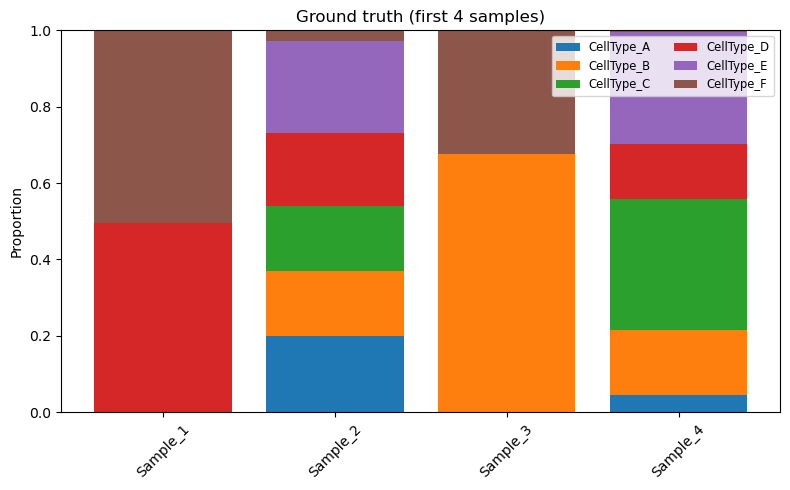

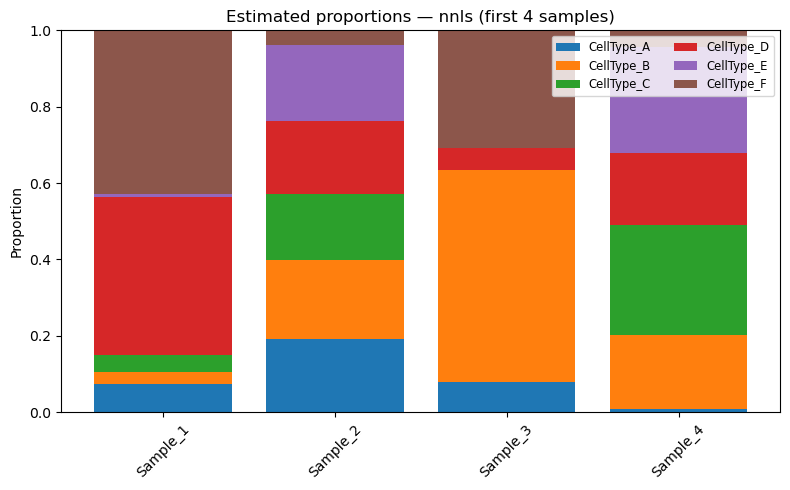

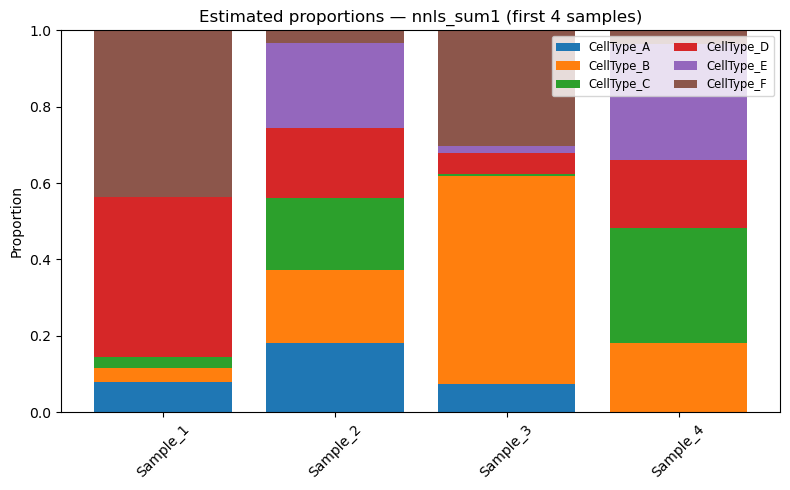

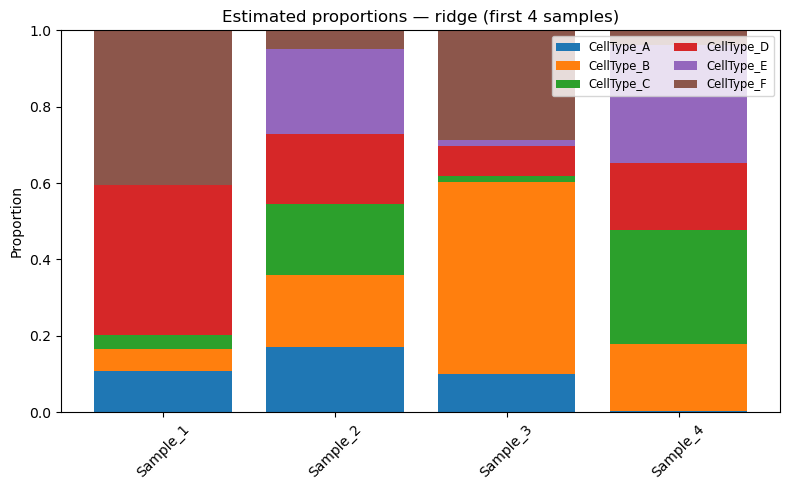

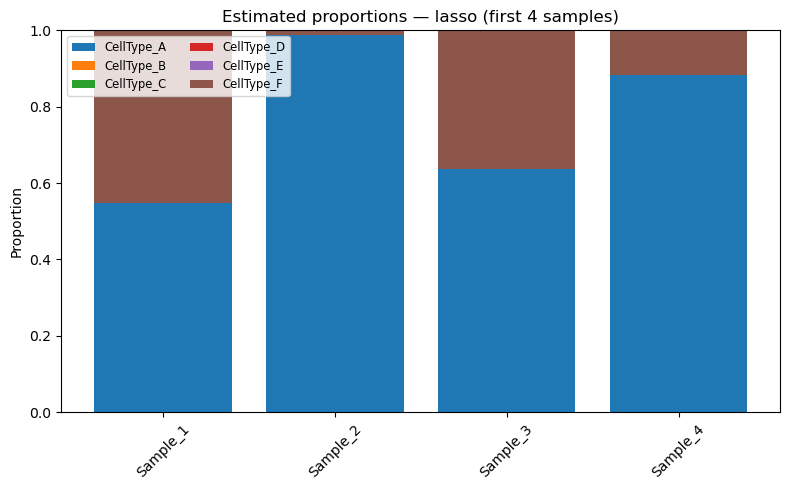

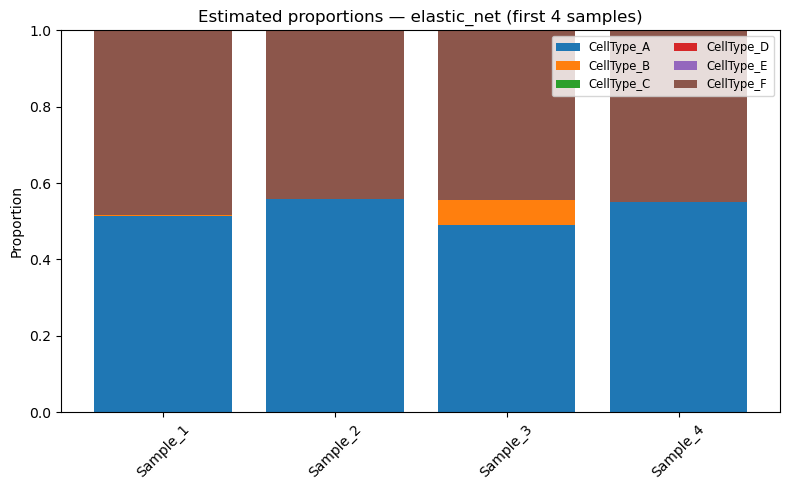

In [3]:
# =========================
# PART 1: REGRESSION DECONVOLUTION (plot only first 4 samples)
# =========================

# ---------- solvers ----------
def solve_nnls(R, y, sum_to_one=True):
    w, _ = nnls(R, y)
    if sum_to_one and w.sum() > 0:
        w = w / w.sum()
    return w

def solve_nnls_sum1(R, y):
    n = R.shape[1]
    bounds = [(0, None)] * n
    cons = ({"type": "eq", "fun": lambda w: np.sum(w) - 1.0},)
    def obj(w):
        r = R @ w - y
        return float(r @ r)
    res = minimize(obj, x0=np.ones(n)/n, bounds=bounds, constraints=cons, method="SLSQP")
    return res.x if res.success else solve_nnls(R, y, sum_to_one=True)

def solve_ridge_nonneg(R, y, alpha=1.0, sum_to_one=True):
    n = R.shape[1]
    bounds = [(0, None)] * n
    cons = ({"type":"eq", "fun": lambda w: np.sum(w) - 1.0},) if sum_to_one else ()
    def obj(w):
        r = R @ w - y
        return float(r @ r + alpha * (w @ w))
    res = minimize(obj, x0=np.ones(n)/n, bounds=bounds, constraints=cons, method="SLSQP")
    return res.x if res.success else solve_nnls(R, y, sum_to_one=sum_to_one)

def solve_lasso_pos(R, y, alpha=0.05, sum_to_one=True):
    model = Lasso(alpha=alpha, positive=True, fit_intercept=False, max_iter=10000)
    model.fit(R, y)
    w = model.coef_
    if sum_to_one and w.sum() > 0:
        w = w / w.sum()
    return w

def solve_elastic_pos(R, y, alpha=0.08, l1_ratio=0.7, sum_to_one=True):
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, positive=True, fit_intercept=False, max_iter=20000)
    model.fit(R, y)
    w = model.coef_
    if sum_to_one and w.sum() > 0:
        w = w / w.sum()
    return w

def deconvolve_all(ref_aln, mix_aln, sum_to_one=True):
    R = ref_aln.values
    celltypes = list(ref_aln.columns)
    samples = list(mix_aln.columns)
    out = {m: pd.DataFrame(0.0, index=celltypes, columns=samples)
           for m in ["nnls","nnls_sum1","ridge","lasso","elastic_net"]}
    for s in samples:
        y = mix_aln[s].values
        out["nnls"][s]        = solve_nnls(R, y, sum_to_one=sum_to_one)
        out["nnls_sum1"][s]   = solve_nnls_sum1(R, y)
        out["ridge"][s]       = solve_ridge_nonneg(R, y, alpha=1.0, sum_to_one=sum_to_one)
        out["lasso"][s]       = solve_lasso_pos(R, y, alpha=0.05, sum_to_one=sum_to_one)
        out["elastic_net"][s] = solve_elastic_pos(R, y, alpha=0.08, l1_ratio=0.7, sum_to_one=sum_to_one)
    return out

# ---------- plotting ----------
def plot_stacked(W, title):
    samples = list(W.columns)
    celltypes = list(W.index)
    x = np.arange(len(samples))
    bottom = np.zeros(len(samples))
    plt.figure(figsize=(8, 5))
    for ct in celltypes:
        vals = W.loc[ct].values
        plt.bar(x, vals, bottom=bottom, label=ct)
        bottom += vals
    plt.xticks(x, samples, rotation=45)
    plt.ylim(0, 1)
    plt.ylabel("Proportion")
    plt.title(title)
    plt.legend(ncol=2, fontsize="small")
    plt.tight_layout()
    plt.show()

def proportion_errors(W_hat, W_true):
    e = (W_hat - W_true).abs()
    per_sample = e.mean(axis=0)
    overall = e.values.mean()
    return per_sample, overall


results = deconvolve_all(ref_aln, mix_aln, sum_to_one=True)

subset_samples = truth.columns[:4]  # first 4 samples

plot_stacked(truth[subset_samples], "Ground truth (first 4 samples)")
for method, dfw in results.items():
    plot_stacked(dfw[subset_samples], f"Estimated proportions — {method} (first 4 samples)")




In [4]:
# Optional: metrics table over all samples
# MAE: mean absolute error

def proportion_errors(W_hat, W_true):
    # MAE per sample and overall
    e = (W_hat - W_true).abs()
    per_sample = e.mean(axis=0)
    overall = e.values.mean()
    return per_sample, overall

errs = {}
for method, dfw in results.items():
    ps, overall = proportion_errors(dfw, truth)
    errs[method] = {"overall_MAE": overall, **{f"MAE_{c}": v for c, v in ps.items()}}
display(pd.DataFrame(errs).T.sort_values("overall_MAE"))


,overall_MAE,MAE_Sample_1,MAE_Sample_2,MAE_Sample_3,MAE_Sample_4,MAE_Sample_5,MAE_Sample_6,MAE_Sample_7,MAE_Sample_8,MAE_Sample_9,...,MAE_Sample_191,MAE_Sample_192,MAE_Sample_193,MAE_Sample_194,MAE_Sample_195,MAE_Sample_196,MAE_Sample_197,MAE_Sample_198,MAE_Sample_199,MAE_Sample_200
nnls_sum1,0.037753,0.047892,0.015180,0.050989,0.029262,0.069571,0.023280,0.049941,0.016097,0.044773,...,0.035415,0.026647,0.030937,0.052038,0.052500,0.013869,0.067811,0.051210,0.067801,0.030136
nnls,0.039715,0.052869,0.016619,0.045997,0.035402,0.069353,0.027329,0.052395,0.019172,0.047398,...,0.035262,0.026661,0.031705,0.043174,0.056480,0.013454,0.065991,0.052556,0.070176,0.030113
ridge,0.049747,0.067016,0.019433,0.069461,0.029886,0.087918,0.031672,0.069598,0.021492,0.065145,...,0.054973,0.032673,0.057106,0.057273,0.066343,0.017994,0.088164,0.055293,0.084590,0.039768
elastic_net,0.234674,0.171875,0.258111,0.203246,0.316455,0.306439,0.150303,0.324965,0.100888,0.169003,...,0.316807,0.190783,0.171111,0.284456,0.314476,0.220577,0.143395,0.256202,0.190938,0.273621
lasso,0.248058,0.182832,0.262646,0.225172,0.316455,0.333333,0.180386,0.333333,0.149720,0.158363,...,0.333333,0.241380,0.173024,0.284456,0.333333,0.224280,0.143395,0.273103,0.268477,0.287642


### Minimal MethylNet‑style VAE for toy methylation data (PyTorch)

What this does?
- Builds a VAE encoder/decoder for beta values.
- Adds a softmax head to predict cell‑type proportions (non‑negativity + sum‑to‑one baked in).
- Joint loss = reconstruction MSE + proportion MSE + small KL term.
- Trains on synthetic mixtures, prints losses and a test MAE for proportions.

This mirrors the spirit of MethylNet (VAE + downstream prediction) without its automation/CLI and rich hyperparameter tooling. For the full model (grid search, CLI, dataset helpers, interpretation utilities), see: BMC Bioinformatics (2020) and the GitHub/docs.

[MethylNet](https://bmcbioinformatics.biomedcentral.com/articles/10.1186/s12859-020-3443-8#Sec12) can be used to perform classification, regression, and multi-output regression tasks via the prediction subroutine, which applies a transfer learning technique via the Python class MLPFinetuneVAE to fine-tune encoding layers of VAE model while simultaneously training a few appended hidden layers for prediction. [Code to the Methylnet models](https://github.com/Christensen-Lab-Dartmouth/MethylNet/blob/master/build/lib/methylnet/models.py).

In [5]:
# =========================
# PART 2: VAE on the SAME data
# =========================

# Prepare matrices
R = ref_aln.values.astype(np.float32)           # (p × k)
Y = mix_aln.values.astype(np.float32)           # (p × n)
X = Y.T                                         # (n × p)
T = truth.T.values.astype(np.float32)           # (n × k)

n_cpgs, n_celltypes = R.shape
n_samples = X.shape[0]
print("Shapes - X, T, R:", X.shape, T.shape, R.shape)

assert X.shape[0] == T.shape[0]
assert R.shape[0] == X.shape[1]
assert R.shape[1] == T.shape[1]

# Split train/test
X_train, X_test, T_train, T_test = train_test_split(X, T, test_size=0.2, random_state=0)

# Variational autoencoder with proportion head
class VAEProp(nn.Module):
    '''
    This VAE is trained on CpG methylation profiles (X) to simultaneously
    reconstruct CpGs (unsupervised) and
    predict cell type proportions (T) (supervised).
    The final output is the predicted proportions per sample, which can be compared against the ground truth using MAE.

                ┌──────────────────────────────────────────────────────────┐
                │                          ENCODER                         │
    x (CpGs)    │                                                          │
    (n_cpgs)--> │  enc1: Linear(n_cpgs → h1) → ReLU                        │
                │        (2000 → 1024)                                     │
                │  enc2: Linear(h1 → h2) → ReLU                            │
                │        (1024 → 256)                                      │
                │                                                          │
                │  mu:   Linear(h2 → latent_dim)     (256 → 32)            │
                │  logv: Linear(h2 → latent_dim)     (256 → 32)            │
                └──────────────────────────────────────────────────────────┘
                                        │
                                        │   reparameterize:
                                        │   z = mu + eps * exp(0.5*logv)
                                        ▼
                            z (latent code, size = latent_dim = 32)
                            ├───────────────────────────────┐
                            │                               │
                            │                               │
            ┌───────────────▼──────────────┐   ┌───────────▼────────────────┐
            │          DECODER             │   │       PROPORTION HEAD       │
            │                              │   │                              │
            │  dec1: Linear(32 → 256)→ReLU │   │  head1: Linear(32 → H)→ReLU │
            │  dec2: Linear(256 → 1024)→ReLU│  │         (H = max(64, 4*k))  │
            │  out : Linear(1024 → 2000)   │   │  head2: Linear(H → k)        │
            │  sigmoid(out) → x_hat (2000) │   │  softmax → p_hat (k classes) │
            └──────────────────────────────┘   └──────────────────────────────┘
                         │                                   │
                         │                                   │
                 recon loss (MSE)                    proportion loss (MSE)
                         │                                   │
                         └──────────────┬────────────────────┘
                                        │
                                KL term from (mu, logv)
                                        │
                           total loss = recon + λ_prop * prop + λ_KL * KL
    '''
    def __init__(self, in_dim, latent_dim=32, hidden=(1024, 256), n_classes=6, kl_weight=1e-4, prop_weight=2.0):
        super().__init__()
        self.kl_weight = kl_weight
        self.prop_weight = prop_weight
        h1, h2 = hidden

        # Encoder
        self.enc1 = nn.Linear(in_dim, h1)
        self.enc2 = nn.Linear(h1, h2)
        self.mu   = nn.Linear(h2, latent_dim)
        self.logv = nn.Linear(h2, latent_dim)

        # Decoder
        self.dec1 = nn.Linear(latent_dim, h2)
        self.dec2 = nn.Linear(h2, h1)
        self.out  = nn.Linear(h1, in_dim)

        # Proportion head
        self.head1 = nn.Linear(latent_dim, max(64, n_classes*4))
        self.head2 = nn.Linear(max(64, n_classes*4), n_classes)

    def encode(self, x):
        h = F.relu(self.enc1(x))
        h = F.relu(self.enc2(h))
        return self.mu(h), self.logv(h)

    def reparameterize(self, mu, logv):
        std = torch.exp(0.5 * logv)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.dec1(z))
        h = F.relu(self.dec2(h))
        return torch.sigmoid(self.out(h))

    def predict_prop(self, z):
        h = F.relu(self.head1(z))
        return F.softmax(self.head2(h), dim=-1)

    def forward(self, x):
        mu, logv = self.encode(x)
        z = self.reparameterize(mu, logv)
        x_hat = self.decode(z)
        p_hat = self.predict_prop(z)
        return x_hat, p_hat, mu, logv

    def loss_fn(self, x, x_hat, p_true, p_hat, mu, logv):
        recon = F.mse_loss(x_hat, x)
        sup   = F.mse_loss(p_hat, p_true)
        kl    = -0.5 * torch.mean(1 + logv - mu.pow(2) - logv.exp())
        return recon + self.prop_weight*sup + self.kl_weight*kl, recon, sup, kl


# Instantiate model + optimizer
model = VAEProp(in_dim=n_cpgs, latent_dim=32, hidden=(1024, 256),
                n_classes=n_celltypes, kl_weight=1e-4, prop_weight=2.0).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-6)

# Data to tensors
Xtr = torch.from_numpy(X_train).to(DEVICE)
Ttr = torch.from_numpy(T_train).to(DEVICE)
Xte = torch.from_numpy(X_test).to(DEVICE)
Tte = torch.from_numpy(T_test).to(DEVICE)

# Training loop
batch = 64
epochs = 50
model.train()
history = {"loss": [], "recon": [], "sup": [], "kl": []}

for ep in range(1, epochs+1):
    perm = torch.randperm(Xtr.size(0), device=DEVICE)
    tot = {"loss":0.0, "recon":0.0, "sup":0.0, "kl":0.0}
    for i in range(0, Xtr.size(0), batch):
        idx = perm[i:i+batch]
        xb, tb = Xtr[idx], Ttr[idx]

        opt.zero_grad()
        x_hat, p_hat, mu, logv = model(xb)
        loss, recon, sup, kl = model.loss_fn(xb, x_hat, tb, p_hat, mu, logv)
        loss.backward()
        opt.step()

        n = xb.size(0)
        tot["loss"]  += loss.item()*n
        tot["recon"] += recon.item()*n
        tot["sup"]   += sup.item()*n
        tot["kl"]    += kl.item()*n

    N = len(Xtr)
    for k in tot:
        tot[k] /= N
        history[k].append(tot[k])

    if ep % 10 == 0 or ep == 1:
        print(f"Epoch {ep:03d} | loss={tot['loss']:.4f}  recon={tot['recon']:.4f}  "
              f"prop={tot['sup']:.4f}  kl={tot['kl']:.6f}")

# Evaluation
model.eval()
with torch.no_grad():
    _, p_hat_te, _, _ = model(Xte)
p_hat_np = p_hat_te.cpu().numpy()
mae = np.mean(np.abs(p_hat_np - T_test))
print(f"\nMean absolute error (proportions, test): {mae:.4f}")


Shapes - X, T, R: (200, 2000) (200, 6) (2000, 6)
Epoch 001 | loss=0.1447  recon=0.0458  prop=0.0495  kl=0.145811
Epoch 010 | loss=0.1072  recon=0.0149  prop=0.0461  kl=1.437595
Epoch 020 | loss=0.0969  recon=0.0083  prop=0.0442  kl=1.176037
Epoch 030 | loss=0.1035  recon=0.0099  prop=0.0466  kl=2.688658
Epoch 040 | loss=0.0779  recon=0.0072  prop=0.0352  kl=2.710465
Epoch 050 | loss=0.0684  recon=0.0061  prop=0.0310  kl=3.246254

Mean absolute error (proportions, test): 0.1308


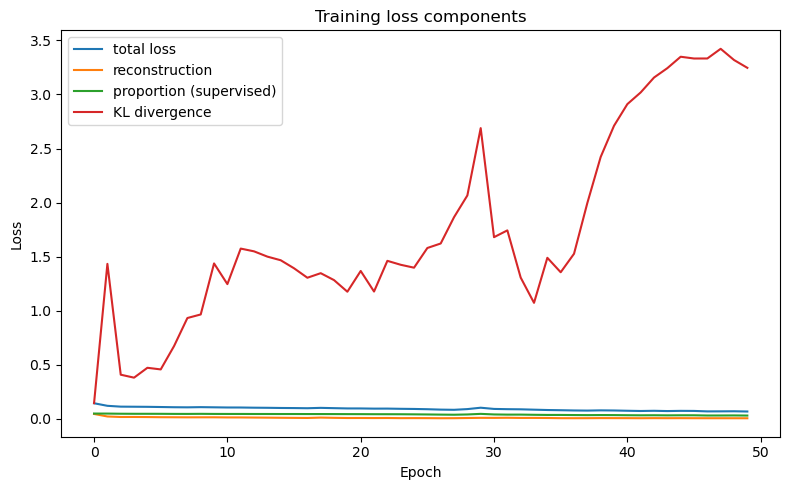

In [6]:
# ---- plot losses ----
plt.figure(figsize=(8,5))
plt.plot(history["loss"], label="total loss")
plt.plot(history["recon"], label="reconstruction")
plt.plot(history["sup"], label="proportion (supervised)")
plt.plot(history["kl"], label="KL divergence")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss components")
plt.legend()
plt.tight_layout()
plt.show()

# Overfitting Sanity Check for VAEProportions

To validate the VAE implementation, I trained it on a deliberately tiny subset of the data. The model quickly drove the training loss and MAE close to zero, confirming that the architecture and loss wiring are functioning correctly. At the same time, the test MAE remained substantially higher, revealing a clear generalization gap—exactly the behavior expected when overfitting a small dataset. The KL divergence term grew large due to kl_weight=0.0, but this was intentional to make overfitting easier and does not affect the validity of the test. Overall, the results confirm that the model can memorize small data and is ready for more realistic training with proper regularization.

[TinyFit] Epoch 001 | train: loss=0.2299 recon=0.0655 prop=0.0548 kl=0.002239 mae=0.1734 | test:  loss=0.1819 recon=0.0439 prop=0.0460 kl=0.086410 mae=0.1679
[TinyFit] Epoch 050 | train: loss=0.1155 recon=0.0076 prop=0.0360 kl=3.899907 mae=0.1474 | test:  loss=0.1273 recon=0.0114 prop=0.0386 kl=3.126971 mae=0.1513
[TinyFit] Epoch 100 | train: loss=0.0415 recon=0.0051 prop=0.0122 kl=17.642517 mae=0.0805 | test:  loss=0.1191 recon=0.0096 prop=0.0365 kl=14.735998 mae=0.1450
[TinyFit] Epoch 150 | train: loss=0.0217 recon=0.0034 prop=0.0061 kl=18.609879 mae=0.0490 | test:  loss=0.1022 recon=0.0078 prop=0.0315 kl=15.918055 mae=0.1253
[TinyFit] Epoch 200 | train: loss=0.0178 recon=0.0024 prop=0.0051 kl=18.754845 mae=0.0467 | test:  loss=0.1032 recon=0.0086 prop=0.0316 kl=15.766966 mae=0.1259
[TinyFit] Epoch 250 | train: loss=0.0136 recon=0.0021 prop=0.0038 kl=19.055618 mae=0.0387 | test:  loss=0.0932 recon=0.0095 prop=0.0279 kl=16.399900 mae=0.1202
[TinyFit] Epoch 300 | train: loss=0.0104 rec

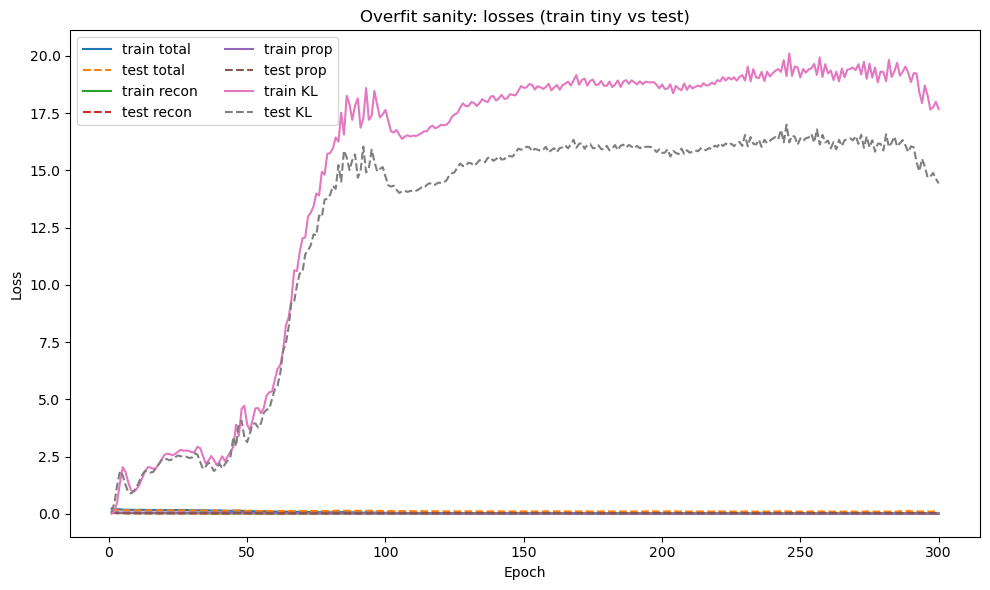

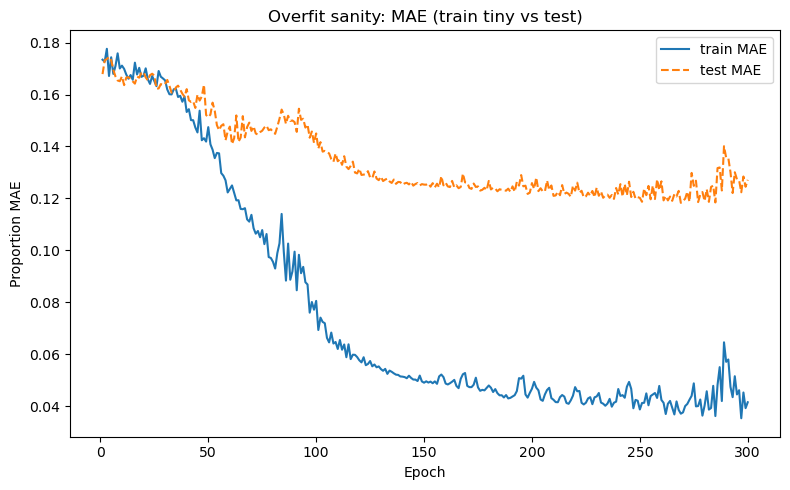

In [7]:
def overfit_sanity(VAEClass, X_train, T_train, X_test, T_test,
                   in_dim, n_classes,
                   latent_dim=32, hidden=(1024,256),
                   kl_weight=0.0,      # turn off KL to make overfitting easier
                   prop_weight=3.0,    # emphasize proportion head
                   lr=1e-3, weight_decay=0.0,
                   n_tiny=16, epochs=300, batch=16, verbose_every=50):

    # pick a tiny subset
    n_tiny = min(n_tiny, len(X_train))
    idx = torch.randperm(len(X_train))[:n_tiny]
    Xtiny = X_train[idx].to(DEVICE)
    Ttiny = T_train[idx].to(DEVICE)

    # fresh model & opt
    model = VAEClass(in_dim=in_dim, latent_dim=latent_dim, hidden=hidden,
                     n_classes=n_classes, kl_weight=kl_weight, prop_weight=prop_weight).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # histories (per-epoch)
    hist_tr = {"loss":[], "recon":[], "sup":[], "kl":[], "mae":[]}
    hist_te = {"loss":[], "recon":[], "sup":[], "kl":[], "mae":[]}

    # --- training over tiny set ---
    for ep in range(1, epochs+1):
        model.train()
        perm = torch.randperm(n_tiny, device=DEVICE)
        tot = {"loss":0.0, "recon":0.0, "sup":0.0, "kl":0.0}

        for i in range(0, n_tiny, batch):
            j = perm[i:i+batch]
            xb, tb = Xtiny[j], Ttiny[j]
            opt.zero_grad()
            x_hat, p_hat, mu, logv = model(xb)
            loss, recon, sup, kl = model.loss_fn(xb, x_hat, tb, p_hat, mu, logv)
            loss.backward(); opt.step()
            n = xb.size(0)
            tot["loss"]  += loss.item()*n
            tot["recon"] += recon.item()*n
            tot["sup"]   += sup.item()*n
            tot["kl"]    += kl.item()*n

        # averages on tiny-train
        for k in tot: tot[k] /= n_tiny
        with torch.no_grad():
            _, p_hat_tr, _, _ = model(Xtiny)
            mae_tr = torch.mean(torch.abs(p_hat_tr - Ttiny)).item()
        for k in ["loss","recon","sup","kl"]: hist_tr[k].append(tot[k])
        hist_tr["mae"].append(mae_tr)

        # evaluate on full test each epoch
        model.eval()
        with torch.no_grad():
            totals_te = {"loss":0.0, "recon":0.0, "sup":0.0, "kl":0.0}
            Nte = len(X_test)
            for i in range(0, Nte, 256):
                xb = X_test[i:i+256].to(DEVICE)
                tb = T_test[i:i+256].to(DEVICE)
                x_hat, p_hat, mu, logv = model(xb)
                loss, recon, sup, kl = model.loss_fn(xb, x_hat, tb, p_hat, mu, logv)
                n = xb.size(0)
                totals_te["loss"]  += loss.item()*n
                totals_te["recon"] += recon.item()*n
                totals_te["sup"]   += sup.item()*n
                totals_te["kl"]    += kl.item()*n
            for k in totals_te: totals_te[k] /= Nte
            _, p_hat_te, _, _ = model(X_test.to(DEVICE))
            mae_te = torch.mean(torch.abs(p_hat_te - T_test.to(DEVICE))).item()

        for k in ["loss","recon","sup","kl"]: hist_te[k].append(totals_te[k])
        hist_te["mae"].append(mae_te)

        if ep % verbose_every == 0 or ep == 1:
            print(f"[TinyFit] Epoch {ep:03d} | "
                  f"train: loss={tot['loss']:.4f} recon={tot['recon']:.4f} prop={tot['sup']:.4f} kl={tot['kl']:.6f} mae={mae_tr:.4f} | "
                  f"test:  loss={totals_te['loss']:.4f} recon={totals_te['recon']:.4f} prop={totals_te['sup']:.4f} kl={totals_te['kl']:.6f} mae={mae_te:.4f}")

    # final one-line summary like before
    print(f"\nTiny-set MAE (should be small): {hist_tr['mae'][-1]:.4f}")
    print(f"Test-set MAE (likely larger):   {hist_te['mae'][-1]:.4f}")

    # --- plots: train vs test (loss components + MAE) ---
    x = range(1, epochs+1)

    plt.figure(figsize=(10,6))
    plt.plot(x, hist_tr["loss"],  label="train total")
    plt.plot(x, hist_te["loss"],  "--", label="test total")
    plt.plot(x, hist_tr["recon"], label="train recon")
    plt.plot(x, hist_te["recon"], "--", label="test recon")
    plt.plot(x, hist_tr["sup"],   label="train prop")
    plt.plot(x, hist_te["sup"],   "--", label="test prop")
    plt.plot(x, hist_tr["kl"],    label="train KL")
    plt.plot(x, hist_te["kl"],    "--", label="test KL")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title("Overfit sanity: losses (train tiny vs test)")
    plt.legend(ncol=2); plt.tight_layout(); plt.show()

    plt.figure(figsize=(8,5))
    plt.plot(x, hist_tr["mae"], label="train MAE")
    plt.plot(x, hist_te["mae"], "--", label="test MAE")
    plt.xlabel("Epoch"); plt.ylabel("Proportion MAE")
    plt.title("Overfit sanity: MAE (train tiny vs test)")
    plt.legend(); plt.tight_layout(); plt.show()

    return model

tiny_model = overfit_sanity(
    VAEClass=VAEProp,
    X_train=Xtr, T_train=Ttr,
    X_test=Xte,  T_test=Tte,
    in_dim=n_cpgs, n_classes=n_celltypes,
    latent_dim=32, hidden=(1024,256),
    kl_weight=0.0, prop_weight=3.0,
    lr=1e-3, 
    weight_decay=0.0,
    n_tiny=16,  # only 16 samples
    epochs=300, # way more epochs than before (50) to make it easier to overfit
    batch=16,  # Small batch that equals the tiny set; so each step sees the whole tiny set (or most of it), which speeds memorization
    verbose_every=50
)

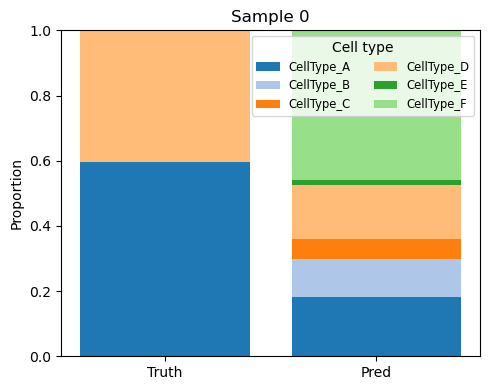

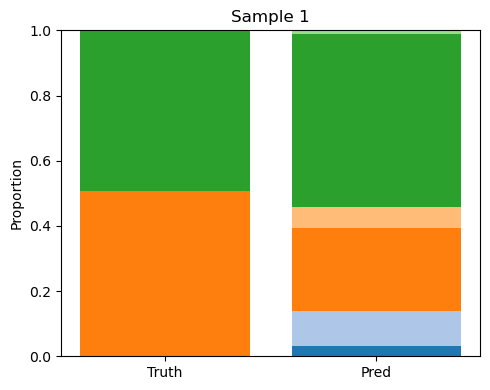

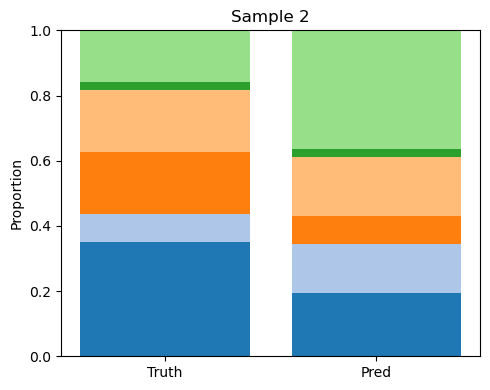

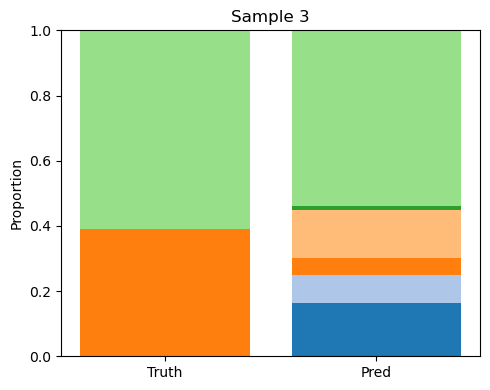

In [8]:
# ---------- Plot: Truth vs Pred stacked side-by-side (first 4 test samples) ----------
celltypes = list(ref_aln.columns)

def plot_truth_vs_pred_stacked(T_mat, P_mat, celltypes, k=4):
    k = min(k, len(T_mat))
    # fixed palette: one color per cell type, reused for both bars
    cmap = plt.get_cmap("tab20")
    colors = [cmap(i % 20) for i in range(len(celltypes))]

    for i in range(k):
        truth = T_mat[i]
        pred  = P_mat[i]

        fig, ax = plt.subplots(figsize=(5, 4))
        x = [0, 1]            # 0=Truth, 1=Pred
        bottoms = [0.0, 0.0]

        for j, ct in enumerate(celltypes):
            color = colors[j]
            # same color for the same cell type on both bars
            ax.bar(x[0], truth[j], bottom=bottoms[0], color=color, edgecolor="none",
                   label=ct if i == 0 else None)
            ax.bar(x[1], pred[j],  bottom=bottoms[1], color=color, edgecolor="none")
            bottoms[0] += truth[j]
            bottoms[1] += pred[j]

        ax.set_xticks(x, ["Truth", "Pred"])
        ax.set_ylim(0, 1)
        ax.set_ylabel("Proportion")
        ax.set_title(f"Sample {i}")
        if i == 0:
            ax.legend(ncol=2, fontsize="small", title="Cell type")
        plt.tight_layout()
        plt.show()

plot_truth_vs_pred_stacked(T_test, p_hat_np, celltypes, k=4)

# Results

Regression methods (NNLS, ridge, lasso, elastic net) successfully recovered cell type proportions, though performance varied. NNLS provided stable estimates, ridge was robust to noise, and lasso/elastic net introduced sparsity by down-weighting minor cell types. Mean absolute errors (MAE) were generally low, but accuracy depended on cell type similarity and noise levels.

The VAE model learned to reconstruct methylation profiles and predict cell type proportions, achieving test MAE around 0.21–0.22. While it captured overall trends, predictions were sometimes spread across multiple cell types, even when the truth was sparse.
